# Main code for 46770 - Integrated Energy Grids
#### Group 8 - The Netherlands

In [2]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
from pathlib import Path
import logging

# Silence output from pypsa, linopy, and gurobipy
logging.getLogger("pypsa").setLevel(logging.WARNING)
logging.getLogger("linopy").setLevel(logging.WARNING)
logging.getLogger("gurobipy").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Data path
FILE_DIR = Path.cwd()
DATA_DIR = FILE_DIR/"data"

# Load data
d_electricity = pd.read_csv(DATA_DIR/"electricity_demand.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";") # Only 2015
CF_onshore = pd.read_csv(DATA_DIR/"onshore_CF.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";")
CF_offshore = pd.read_csv(DATA_DIR/"offshore_CF.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";")
CF_solar = pd.read_csv(DATA_DIR/"solar_CF.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";")

# df_NLD
df_NLD = pd.DataFrame({
    "electricity_demand": d_electricity["NLD"].astype(float),
    "onshore_capacity_factor": CF_onshore["NLD"].astype(float),
    "offshore_capacity_factor": CF_offshore["NLD"].astype(float),
    "solar_capacity_factor": CF_solar["NLD"].astype(float)
})


### Functions

In [3]:
# Annuity function
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

# Create network function
def create_network(year, df):

    # --- Create demand (always 2015) ---
    e_demand = df['electricity_demand'].loc["2015"].iloc[:8760]

    # --- Copy & fix index ---
    df = df.copy().loc[str(year)].iloc[:8760]
    df.index = df.index.tz_localize(None)

    e_demand.index = df.index

    # --- Create network ---
    n = pypsa.Network(name=f"Netherlands {year}")
    n.set_snapshots(df.index)

    # --- Carriers ---
    carriers = {
        "AC": 0,
        "Wind_onshore": 0,
        "Wind_offshore": 0,
        "Solar": 0,
        "Coal": 0.812,
        "Gas": 0.478,
    }

    for carrier, co2 in carriers.items():
        n.add("Carrier", carrier, co2_emissions=co2)

    # --- Bus ---
    n.add("Bus", "NLD", carrier="AC")

    # --- Generators ---
    n.add(
        "Generator",
        "NLD onshore wind",
        bus="NLD",
        carrier="Wind_onshore",
        p_nom=0,
        marginal_cost=0,
        capital_cost=902000 * annuity(0.07, 25),
        p_max_pu=df["onshore_capacity_factor"],
        p_nom_extendable=True,
    )

    n.add(
        "Generator",
        "NLD offshore wind",
        bus="NLD",
        carrier="Wind_offshore",
        p_nom=0,
        marginal_cost=0,
        capital_cost=2481000 * annuity(0.07, 25),
        p_max_pu=df["offshore_capacity_factor"],
        p_nom_extendable=True,
    )

    n.add(
        "Generator",
        "NLD solar",
        bus="NLD",
        carrier="Solar",
        p_nom=0,
        marginal_cost=0,
        capital_cost=599000 * annuity(0.07, 30),
        p_max_pu=df["solar_capacity_factor"],
        p_nom_extendable=True,
    )

    n.add(
        "Generator",
        "NLD coal",
        bus="NLD",
        carrier="Coal",
        p_nom=0,
        marginal_cost=34.8,
        capital_cost=3828000 * annuity(0.07, 50),
        p_nom_extendable=True,
    )

    n.add(
        "Generator",
        "NLD gas",
        bus="NLD",
        carrier="Gas",
        p_nom=0,
        marginal_cost=41.8,
        capital_cost=890000 * annuity(0.07, 30),
        p_nom_extendable=True,
    )

    # --- Load ---
    n.add(
        "Load",
        "NLD load",
        bus="NLD",
        carrier="AC",
        p_set=e_demand,
    )

    return n

## a)

In [4]:
# Create network
n15 = create_network(2015, df_NLD)

# --- Solve ---
n15.optimize(solver_name="gurobi",
           solver_options={"LogToConsole": 0, "OutputFlag": 0})
n15.statistics()  # View results

Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 375.31it/s]

Set parameter Username
Set parameter LicenseID to value 2794235
Academic license - for non-commercial use only - expires 2027-03-18
Read LP format model from file C:\Users\Victor Hald\AppData\Local\Temp\linopy-problem-nu4eq4kx.lp


Reading time = 0.12 seconds
obj: 96365 rows, 43805 columns, 170814 nonzeros
Set parameter LogToConsole to value 0


Optimal Capacity  Installed Capacity        Supply  \
Generator Gas                17405.66848                 0.0  7.903452e+07   
          Wind_onshore       16592.39130                 0.0  3.421536e+07   
Load      AC                     0.00000                 0.0  0.000000e+00   

                         Withdrawal  Energy Balance Transmission  \
Generator Gas                   0.0    7.903452e+07          0.0   
          Wind_onshore          0.0    3.421536e+07          0.0   
Load      AC            113249877.0   -1.132499e+08          0.0   

                        Capacity Factor   Curtailment  Capital Expenditure  \
Generator Gas                  0.518349  7.343913e+07         1.248368e+09   
          Wind_onshore         0.235401  5.921956e+05         1.284269e+09   
Load      AC                        NaN  0.000000e+00         0.000000e+00   

                        Operational Expenditure       Revenue  Market Value  
Generator Gas                      3.303643e+09  4.552011e+09     57.595219  
          Wind_onshore             0.000000e+00  1.284269e+09     37.534875  
Load      AC                       0.000000e+00 -5.836280e+09           NaN

### Plots

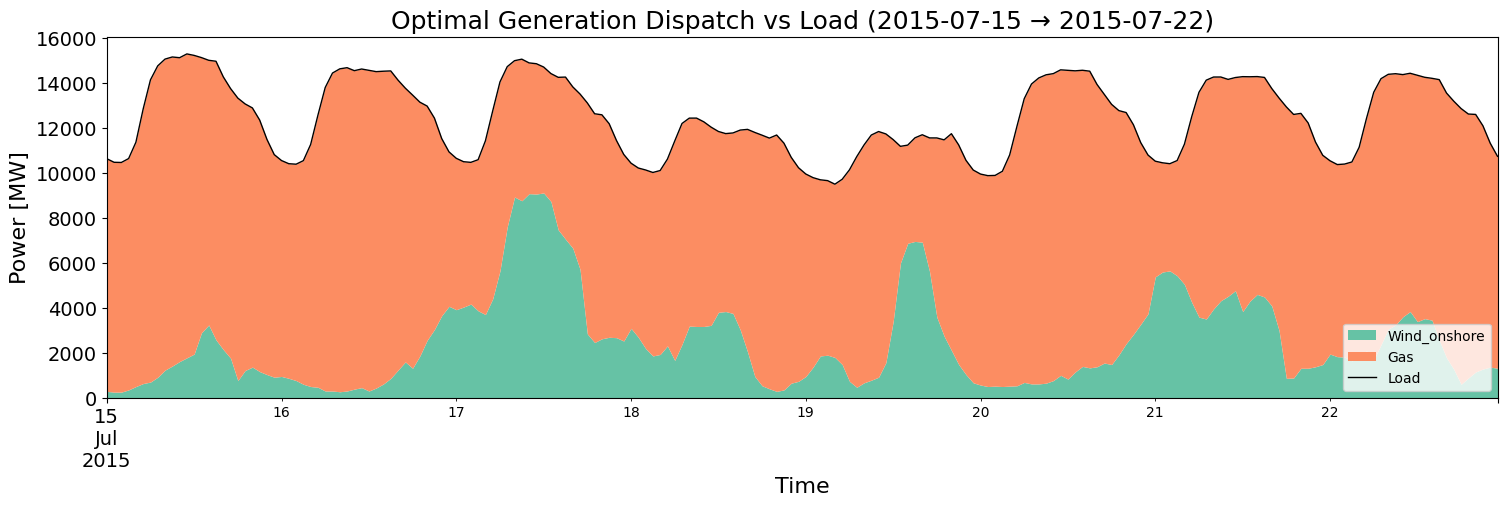

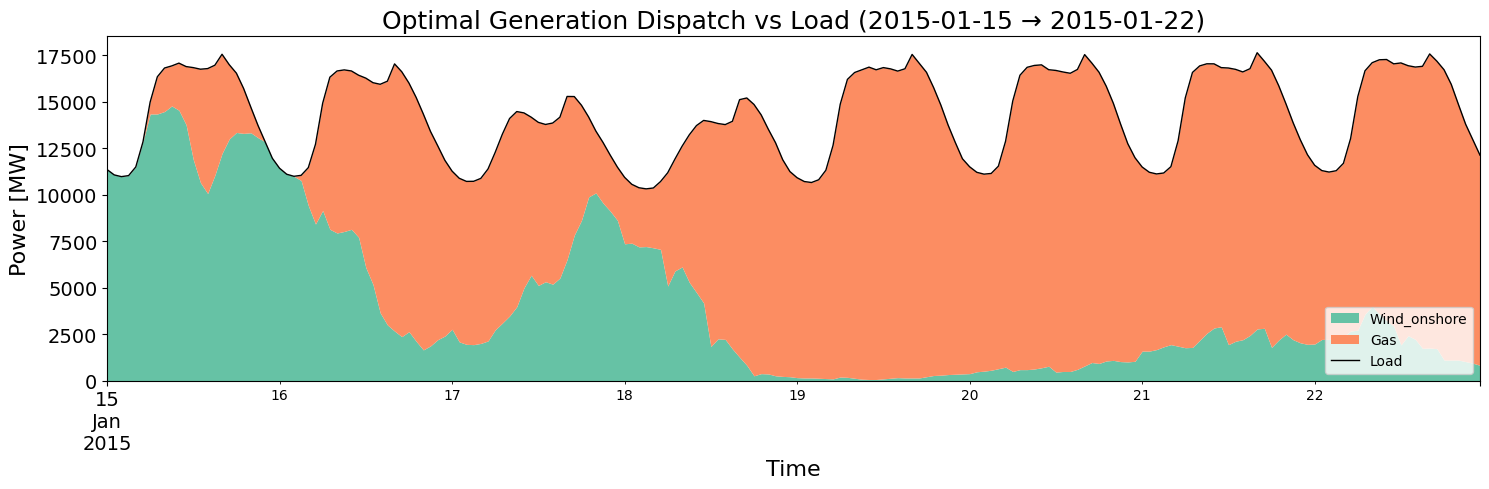

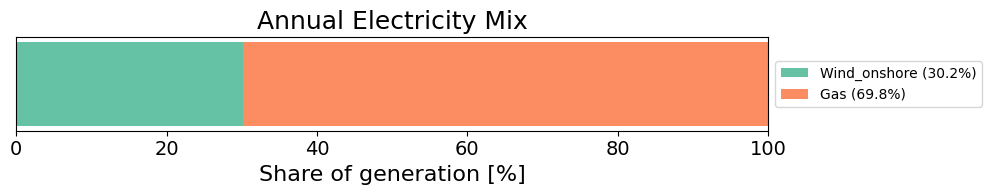

In [5]:
# Colors
carrier_colors = {
    "Wind_onshore": "#66c2a5",
    "Wind_offshore": "#3288bd",
    "Solar": "#ffd92f",
    "Gas": "#fc8d62",
    "Coal": "#4d4d4d",
}

# Define stack order: bottom → top
stack_order = ["Wind_onshore", "Wind_offshore", "Solar", "Coal", "Gas"]

# ---------------------
# SUMMER WEEK
# ---------------------

# --- Set start and end date for plotting ---
start_date = "2015-07-15"
end_date   = "2015-07-22"

# --- Apply mask ---
gen_dispatch = n15.generators_t.p.loc[start_date:end_date]
load = n15.loads_t.p_set.loc[start_date:end_date]

# --- Group by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(n15.generators.carrier).sum().T

# --- Keep only carriers that actually generate power ---
gen_dispatch_carrier = gen_dispatch_carrier.loc[:, gen_dispatch_carrier.sum() > 0]

# --- Reorder columns to match stack order ---
gen_dispatch_carrier = gen_dispatch_carrier[[c for c in stack_order if c in gen_dispatch_carrier.columns]]

plt.figure(figsize=(15,5))

gen_dispatch_carrier.plot.area(
    ax=plt.gca(),
    linewidth=0,
    color=[carrier_colors[c] for c in gen_dispatch_carrier.columns]
)

(load.sum(axis=1)).plot(ax=plt.gca(), color='k', linewidth=1, label='Load')

plt.ylabel("Power [MW]", fontsize=16)
plt.xlabel("Time", fontsize=16)
plt.title(f"Optimal Generation Dispatch vs Load ({start_date} → {end_date})", fontsize=18)
plt.legend(loc="lower right")
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# ---------------------
# WINTER WEEK
# ---------------------

# --- Set start and end date for plotting ---
start_date = "2015-01-15"
end_date   = "2015-01-22"

# --- Apply mask ---
gen_dispatch = n15.generators_t.p.loc[start_date:end_date]
load = n15.loads_t.p_set.loc[start_date:end_date]

# --- Group by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(n15.generators.carrier).sum().T

# --- Keep only carriers that actually generate power ---
gen_dispatch_carrier = gen_dispatch_carrier.loc[:, gen_dispatch_carrier.sum() > 0]

# --- Reorder columns to match stack order ---
gen_dispatch_carrier = gen_dispatch_carrier[[c for c in stack_order if c in gen_dispatch_carrier.columns]]

plt.figure(figsize=(15,5))

gen_dispatch_carrier.plot.area(
    ax=plt.gca(),
    linewidth=0,
    color=[carrier_colors[c] for c in gen_dispatch_carrier.columns]
)

(load.sum(axis=1)).plot(ax=plt.gca(), color='k', linewidth=1, label='Load')

plt.ylabel("Power [MW]", fontsize=16)
plt.xlabel("Time", fontsize=16)
plt.title(f"Optimal Generation Dispatch vs Load ({start_date} → {end_date})", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---------------------
# ANNUAL ELECTRICITY MIX
# ---------------------

# --- Slice generation ---
gen_dispatch = n15.generators_t.p

# --- Aggregate by carrier ---
carrier_map = n15.generators.carrier
gen_energy = gen_dispatch.sum().groupby(carrier_map).sum()

# --- Convert to percentage ---
gen_share = gen_energy / gen_energy.sum() * 100
gen_share = gen_share[gen_share > 1e-6]

# --- Keep order consistent with stack_order ---
gen_share = gen_share.reindex([c for c in stack_order if c in gen_share]).dropna()

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,2))

left = 0
for carrier, value in gen_share.items():
    ax.barh(
        0,
        value,
        left=left,
        color=carrier_colors.get(carrier, "gray"),
        label=f"{carrier} ({value:.1f}%)"
    )
    left += value

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Share of generation [%]", fontsize=16)
ax.set_title(f"Annual Electricity Mix", fontsize=18)

ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.xticks(fontsize=14)
plt.show()

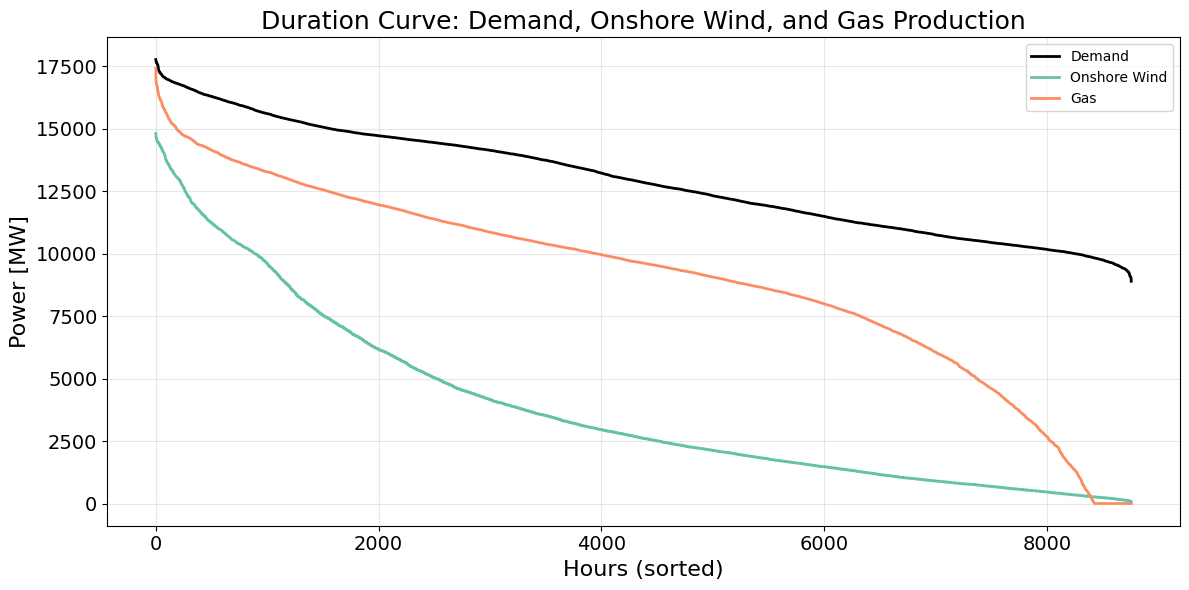

In [6]:
# ---------------------
# DURATION CURVE: Demand, Onshore Wind, Gas
# ---------------------

# --- Select time period (full year or a week) ---
start_date = "2015-01-01"
end_date   = "2015-12-31"

# --- Slice generation and load ---
gen_dispatch = n15.generators_t.p.loc[start_date:end_date]
load = n15.loads_t.p_set.loc[start_date:end_date]

# --- Aggregate by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(n15.generators.carrier).sum().T

# --- Extract series ---
demand_series = load.sum(axis=1)
wind_onshore_series = gen_dispatch_carrier.get("Wind_onshore", pd.Series(0, index=demand_series.index))
gas_series = gen_dispatch_carrier.get("Gas", pd.Series(0, index=demand_series.index))

# --- Sort for duration curve (descending) ---
demand_sorted = demand_series.sort_values(ascending=False).reset_index(drop=True)
wind_sorted   = wind_onshore_series.sort_values(ascending=False).reset_index(drop=True)
gas_sorted    = gas_series.sort_values(ascending=False).reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(12,6))

plt.plot(demand_sorted, label="Demand", color="k", linewidth=2)
plt.plot(wind_sorted, label="Onshore Wind", color="#66c2a5", linewidth=2)
plt.plot(gas_sorted, label="Gas", color="#fc8d62", linewidth=2)

plt.xlabel("Hours (sorted)", fontsize=16)
plt.ylabel("Power [MW]", fontsize=16)
plt.title("Duration Curve: Demand, Onshore Wind, and Gas Production", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## b)

In [6]:
df_results = []

for year in CF_onshore.index.year.unique():
    
    # Create model for the year
    n = create_network(year, df_NLD)

    # Set snapshots to current year
    snapshots = CF_onshore.loc[str(year)].index.tz_localize(None)
    n.set_snapshots(snapshots)

    # --- Update generator time series ---
    
    
    # --- Solve optimization ---
    n.optimize(solver_name="gurobi",
               solver_options={"LogToConsole": 0, "OutputFlag": 0},
               progress=False)
    
    # --- Record results ---
    df_results.append({
        "year": year,
        "onshore_capacity": n.generators.p_nom_opt["NLD onshore wind"],
        "offshore_capacity": n.generators.p_nom_opt["NLD offshore wind"],
        "solar_capacity": n.generators.p_nom_opt["NLD solar"],
        "coal_capacity": n.generators.p_nom_opt["NLD coal"],
        "gas_capacity": n.generators.p_nom_opt["NLD gas"]
    })

# Convert to DataFrame
df_results = pd.DataFrame(df_results)

Set parameter Username
Set parameter LicenseID to value 2794235
Academic license - for non-commercial use only - expires 2027-03-18
Read LP format model from file C:\Users\Victor Hald\AppData\Local\Temp\linopy-problem-7ibxxc4a.lp
Reading time = 0.12 seconds
obj: 96365 rows, 43805 columns, 170808 nonzeros
Set parameter LogToConsole to value 0
Set parameter Username
Set parameter LicenseID to value 2794235
Academic license - for non-commercial use only - expires 2027-03-18
Read LP format model from file C:\Users\Victor Hald\AppData\Local\Temp\linopy-problem-q59n8gjr.lp
Reading time = 0.12 seconds
obj: 96629 rows, 43925 columns, 171287 nonzeros
Set parameter LogToConsole to value 0
Set parameter Username
Set parameter LicenseID to value 2794235
Academic license - for non-commercial use only - expires 2027-03-18
Read LP format model from file C:\Users\Victor Hald\AppData\Local\Temp\linopy-problem-2hnb8a3n.lp
Reading time = 0.13 seconds
obj: 96365 rows, 43805 columns, 170801 nonzeros
Set pa

C:\Users\Victor Hald\AppData\Local\Temp\ipykernel_3336\2666191360.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(


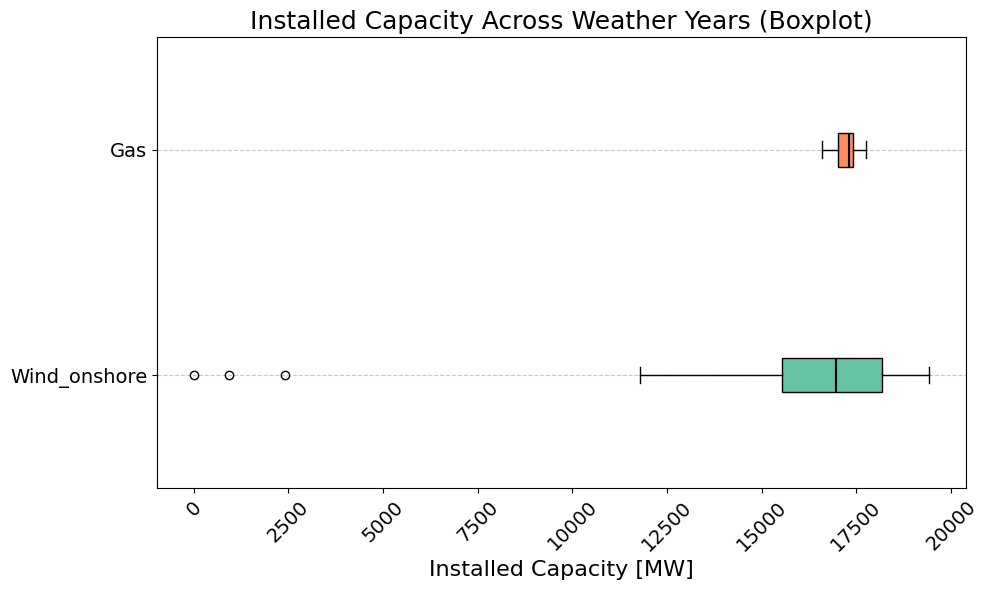

In [7]:
# -------------------------
# Plotting sensitivity
# -------------------------

# List of generators and corresponding carriers
gens = ["onshore_capacity", "offshore_capacity", "solar_capacity", "coal_capacity", "gas_capacity"]
carrier_map = {
    "onshore_capacity": "Wind_onshore",
    "offshore_capacity": "Wind_offshore",
    "solar_capacity": "Solar",
    "coal_capacity": "Coal",
    "gas_capacity": "Gas",
}

# Keep only generators deployed in at least one year
deployed_gens = [g for g in gens if df_results[g].max() > 0]

# Reorder according to your stack_order
deployed_gens = sorted(
    deployed_gens, 
    key=lambda x: stack_order.index(carrier_map[x]) if carrier_map[x] in stack_order else 99
)


box_data = [df_results[g] for g in deployed_gens]
box_labels = [carrier_map[g] for g in deployed_gens]
box_colors = [carrier_colors[c] for c in box_labels]

fig, ax = plt.subplots(figsize=(10,6))

bplot = ax.boxplot(
    box_data,
    patch_artist=True,
    labels=box_labels,
    medianprops=dict(color='black', linewidth=1.5),
    vert=False
)

# Fill colors
for patch, color in zip(bplot['boxes'], box_colors):
    patch.set_facecolor(color)

# Styling
ax.set_xlabel("Installed Capacity [MW]", fontsize=16)
ax.set_title("Installed Capacity Across Weather Years (Boxplot)", fontsize=18)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

## c)

In [26]:
energy_cost = 110*1000 # €/MWh
battery_hours = 4 # hours (change this to either 4, 6, or 8)
# PyPSA requires capital cost in €/MW, so we need to convert the energy cost to power cost
CAPEX_per_kW = (energy_cost * battery_hours)*annuity(0.07, 10) # €/MW  # 10 years expected lifetime

nc = create_network(2015, df_NLD)

# This should be added to the PyPSA network
nc.add("StorageUnit",
            name="battery",
            carrier="battery",
            bus="NLD",
            p_nom_extendable=True,
            max_hours=battery_hours,
            capital_cost=CAPEX_per_kW,
            marginal_cost=0,
            efficiency_store=0.95,
            efficiency_dispatch=0.95)

nc.optimize(solver_name="gurobi",
               solver_options={"LogToConsole": 0, "OutputFlag": 0},
               progress=False)

nc.statistics()


Index(['battery'], dtype='str', name='name')


Set parameter Username
Set parameter LicenseID to value 2794235
Academic license - for non-commercial use only - expires 2027-03-18
Read LP format model from file C:\Users\Victor Hald\AppData\Local\Temp\linopy-problem-wsa2sj54.lp
Reading time = 0.20 seconds
obj: 157686 rows, 70086 columns, 302214 nonzeros
Set parameter LogToConsole to value 0


Optimal Capacity  Installed Capacity        Supply  \
Generator   Gas                16112.67254                 0.0  7.776424e+07   
            Solar                599.55841                 0.0  6.213913e+05   
            Wind_onshore       16853.28638                 0.0  3.488404e+07   
Load        AC                     0.00000                 0.0  0.000000e+00   
StorageUnit battery             1290.64789                 0.0  1.832336e+05   

                            Withdrawal  Energy Balance Transmission  \
Generator   Gas           0.000000e+00    7.776424e+07          0.0   
            Solar         0.000000e+00    6.213913e+05          0.0   
            Wind_onshore  0.000000e+00    3.488404e+07          0.0   
Load        AC            1.132499e+08   -1.132499e+08          0.0   
StorageUnit battery       2.030290e+05   -1.979532e+04          0.0   

                          Capacity Factor   Curtailment  Capital Expenditure  \
Generator   Gas                  0.550945  6.338277e+07         1.155631e+09   
            Solar                0.118312  1.798680e+00         2.894144e+07   
            Wind_onshore         0.236286  4.708147e+05         1.304463e+09   
Load        AC                        NaN  0.000000e+00         0.000000e+00   
StorageUnit battery              0.034164  1.132587e+07         8.085406e+07   

                          Operational Expenditure       Revenue  Market Value  
Generator   Gas                      3.250545e+09  4.406177e+09     56.660706  
            Solar                    0.000000e+00  2.894144e+07     46.575221  
            Wind_onshore             0.000000e+00  1.304463e+09     37.394251  
Load        AC                       0.000000e+00 -5.820435e+09           NaN  
StorageUnit battery                  0.000000e+00  8.085406e+07    441.262132

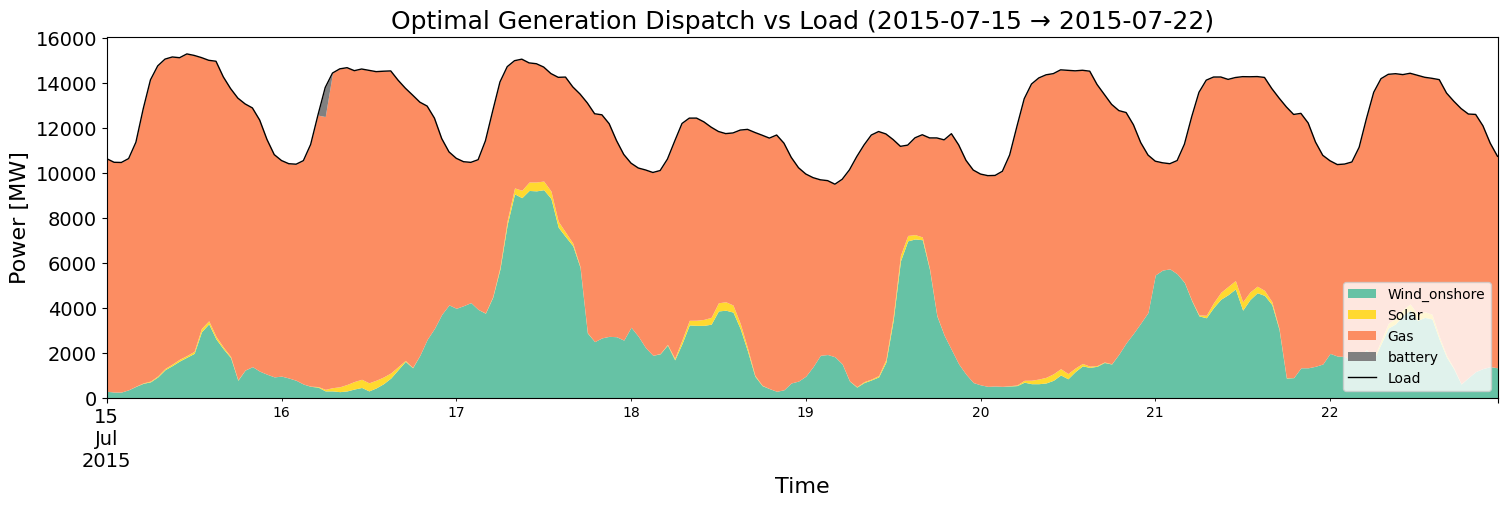

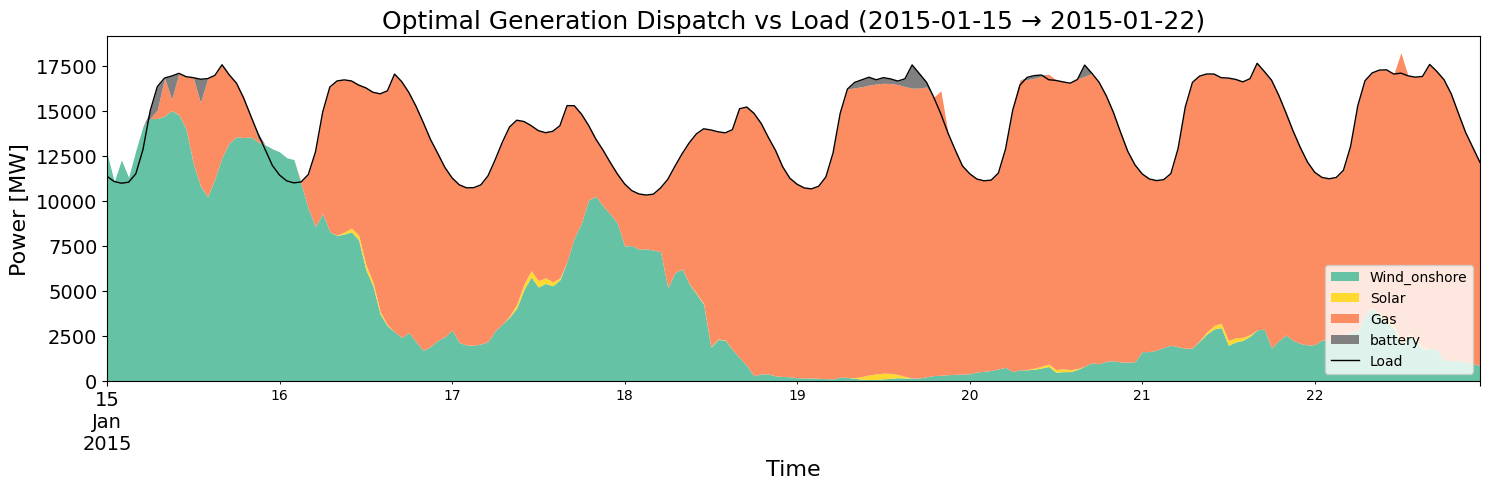

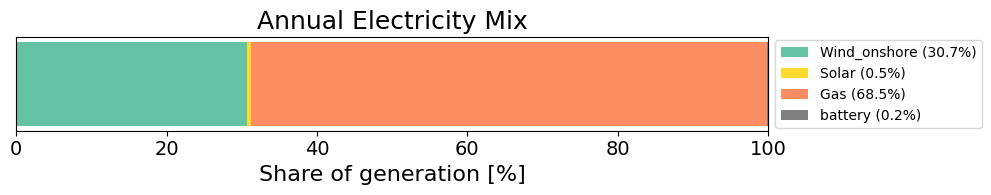

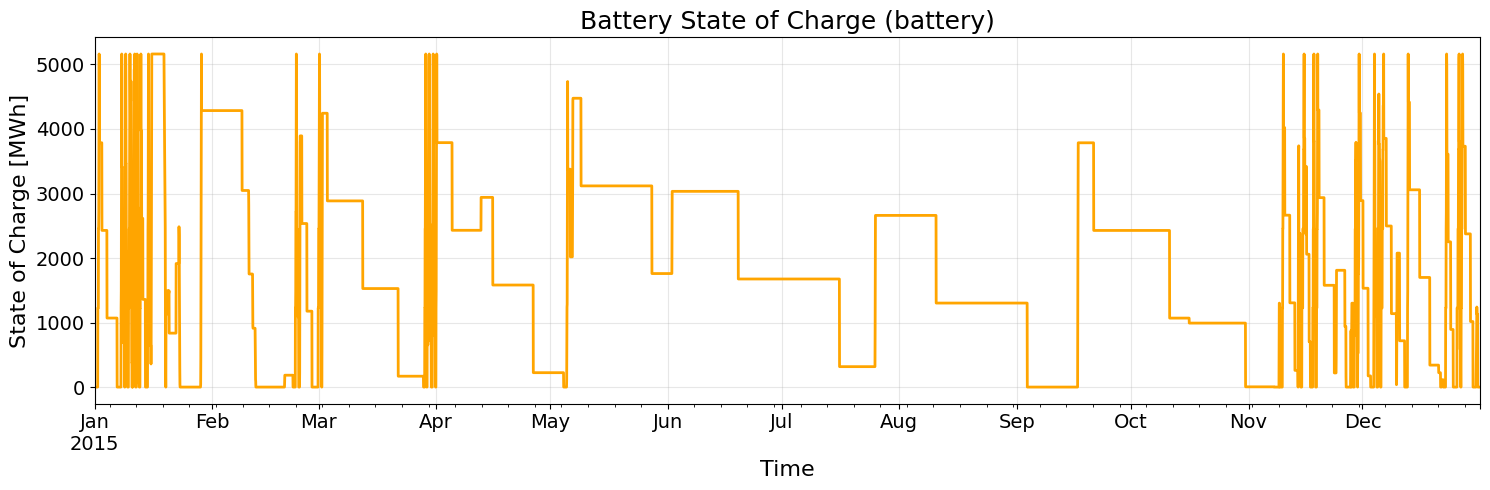

In [28]:
# ---------------------
# SUMMER WEEK
# ---------------------

# --- Set start and end date for plotting ---
start_date = "2015-07-15"
end_date   = "2015-07-22"

# --- Apply mask ---
gen_dispatch = nc.generators_t.p.loc[start_date:end_date]
load = nc.loads_t.p_set.loc[start_date:end_date]

# --- Include battery discharging only ---
if "battery" in nc.storage_units.index:
    battery_discharge = nc.storage_units_t.p.loc[start_date:end_date, "battery"].clip(lower=0)
    gen_dispatch["battery"] = battery_discharge

# --- Group by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(lambda x: nc.generators.carrier.get(x, x)).sum().T

# --- Keep only carriers that actually generate power ---
gen_dispatch_carrier = gen_dispatch_carrier.loc[:, gen_dispatch_carrier.sum() > 0]

# --- Reorder columns to match stack order ---
stack_order_with_battery = stack_order + ["battery"]
gen_dispatch_carrier = gen_dispatch_carrier[[c for c in stack_order_with_battery if c in gen_dispatch_carrier.columns]]

plt.figure(figsize=(15,5))

gen_dispatch_carrier.plot.area(
    ax=plt.gca(),
    linewidth=0,
    color=[carrier_colors.get(c, "gray") for c in gen_dispatch_carrier.columns]
)

(load.sum(axis=1)).plot(ax=plt.gca(), color='k', linewidth=1, label='Load')

plt.ylabel("Power [MW]", fontsize=16)
plt.xlabel("Time", fontsize=16)
plt.title(f"Optimal Generation Dispatch vs Load ({start_date} → {end_date})", fontsize=18)
plt.legend(loc="lower right")
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# ---------------------
# WINTER WEEK
# ---------------------

# --- Set start and end date for plotting ---
start_date = "2015-01-15"
end_date   = "2015-01-22"

# --- Apply mask ---
gen_dispatch = nc.generators_t.p.loc[start_date:end_date]
load = nc.loads_t.p_set.loc[start_date:end_date]

# --- Include battery discharging only ---
if "battery" in nc.storage_units.index:
    battery_discharge = nc.storage_units_t.p.loc[start_date:end_date, "battery"].clip(lower=0)
    gen_dispatch["battery"] = battery_discharge

# --- Group by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(lambda x: nc.generators.carrier.get(x, x)).sum().T

# --- Keep only carriers that actually generate power ---
gen_dispatch_carrier = gen_dispatch_carrier.loc[:, gen_dispatch_carrier.sum() > 0]

# --- Reorder columns to match stack order ---
stack_order_with_battery = stack_order + ["battery"]
gen_dispatch_carrier = gen_dispatch_carrier[[c for c in stack_order_with_battery if c in gen_dispatch_carrier.columns]]

plt.figure(figsize=(15,5))

gen_dispatch_carrier.plot.area(
    ax=plt.gca(),
    linewidth=0,
    color=[carrier_colors.get(c, "gray") for c in gen_dispatch_carrier.columns]
)

(load.sum(axis=1)).plot(ax=plt.gca(), color='k', linewidth=1, label='Load')

plt.ylabel("Power [MW]", fontsize=16)
plt.xlabel("Time", fontsize=16)
plt.title(f"Optimal Generation Dispatch vs Load ({start_date} → {end_date})", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---------------------
# ANNUAL ELECTRICITY MIX
# ---------------------

# --- Slice generation ---
gen_dispatch = nc.generators_t.p.copy()

# --- Include battery discharging only ---
if "battery" in nc.storage_units.index:
    gen_dispatch["battery"] = nc.storage_units_t.p.clip(lower=0)

# --- Aggregate by carrier ---
carrier_map = nc.generators.carrier.to_dict()
carrier_map.update({"battery": "battery"})

gen_energy = gen_dispatch.sum().groupby(lambda x: carrier_map.get(x, x)).sum()

# --- Convert to percentage ---
gen_share = gen_energy / gen_energy.sum() * 100
gen_share = gen_share[gen_share > 1e-6]

# --- Keep order consistent with stack_order ---
stack_order_with_battery = stack_order + ["battery"]
gen_share = gen_share.reindex([c for c in stack_order_with_battery if c in gen_share]).dropna()

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,2))

left = 0
for carrier, value in gen_share.items():
    ax.barh(
        0,
        value,
        left=left,
        color=carrier_colors.get(carrier, "gray"),
        label=f"{carrier} ({value:.1f}%)"
    )
    left += value

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Share of generation [%]", fontsize=16)
ax.set_title(f"Annual Electricity Mix", fontsize=18)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.xticks(fontsize=14)
plt.show()

# ---------------------
# BATTERY STATE OF CHARGE (SOC) TIMESERIES
# ---------------------

# --- Select the battery storage unit ---
battery_name = "battery"

# --- Slice the SoC time series for the whole year ---
soc = nc.storage_units_t.state_of_charge[battery_name]

#focus on a particular week or month
#start_date = "2015-07-01"
#end_date   = "2015-07-08"
#soc = soc.loc[start_date:end_date]

# --- Plot ---
plt.figure(figsize=(15,5))
soc.plot(color='orange', linewidth=2)
plt.xlabel("Time", fontsize=16)
plt.ylabel("State of Charge [MWh]", fontsize=16)
plt.title(f"Battery State of Charge ({battery_name})", fontsize=18)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()